### Tổng quan 
`cat_id` là nhóm sản phẩm lớn nhất có 3 loại:
FOODS: thực phẩm
HOUSEHOLD: đồ gia dụng/ đồ dùng gia đình
HOBBIES: đồ sở thích/ giải trí

`dept_id` là nhóm nhỏ hơn nằm trong category gồm 7 loại:
FOODS_1
FOODS_2
FOODS_3
HOUSEHOLD_1
HOUSEHOLD_2
HOBBIES_1
HOBBIES_2

`item_id` là sản phẩm cụ thể nhất: nghĩa là sản phẩm cụ thể số 001 thuộc department FOODSS_3, và department đó thuộc category FOODS. Tức có 3,049 sản phẩm khác nhau

`store_id` 10 cửa hàng

`series` một cặp item-store


`SNAP`: Supplemental Nutrition Assistance Program: Chương trình hỗ trợ thực phẩm nghĩa là nhà nước hỗ trợ tiền hoặc quyền lợi để người thu nhập thấp mua đồ ăn thiết yếu.

Người đủ điều kiện sẽ được cấp một khoản tiền hằng tháng
→ tiền này nằm trong thẻ điện tử
→ họ dùng thẻ đó để mua thực phẩm ở siêu thị/cửa hàng

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.3f}".format)

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "m5-forecasting-accuracy"

SALES_PATH = DATA_DIR / "sales_train_evaluation.csv"
CALENDAR_PATH = DATA_DIR / "calendar.csv"
PRICES_PATH = DATA_DIR / "sell_prices.csv"

print("Project root:", PROJECT_ROOT)
print("M5 data dir:", DATA_DIR)
print("Sales exists:", SALES_PATH.exists())
print("Calendar exists:", CALENDAR_PATH.exists())
print("Prices exists:", PRICES_PATH.exists())

Project root: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project
M5 data dir: /Users/tnhatnguyendev2805/Documents/University/Data Science/Final Project/data/m5-forecasting-accuracy
Sales exists: True
Calendar exists: True
Prices exists: True


### Đọc metadata cơ bản

In [10]:
calendar = pd.read_csv(CALENDAR_PATH, parse_dates=["date"])
prices = pd.read_csv(
    PRICES_PATH,
    dtype={
        "store_id": "string",
        "item_id": "string",
        "wm_yr_wk": "int32",
        "sell_price": "float32",
    },
)

sales_header = pd.read_csv(SALES_PATH, nrows=0)
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
d_cols = [c for c in sales_header.columns if c.startswith("d_")]

sales_ids = pd.read_csv(
    SALES_PATH,
    usecols=id_cols,
    dtype={c: "string" for c in id_cols},
)

print("Calendar shape:", calendar.shape)
print("Prices shape:", prices.shape)
print("Sales series:", sales_ids.shape[0])
print("Number of day columns:", len(d_cols))
print("First day col:", d_cols[0])
print("Last day col:", d_cols[-1])

display(calendar.head())
display(prices.head())
display(sales_ids.head())

Calendar shape: (1969, 14)
Prices shape: (6841121, 4)
Sales series: 30490
Number of day columns: 1941
First day col: d_1
Last day col: d_1941


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.580
1,CA_1,HOBBIES_1_001,11326,9.580
2,CA_1,HOBBIES_1_001,11327,8.260
3,CA_1,HOBBIES_1_001,11328,8.260
4,CA_1,HOBBIES_1_001,11329,8.260


,id,item_id,dept_id,cat_id,store_id,state_id
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA


### Tạo calendar features

In [11]:
cal_train = calendar[calendar["d"].isin(d_cols)].copy() # lấy các này có trong tập train

cal_train["day_of_week"] = cal_train["date"].dt.day_name()
cal_train["is_weekend"] = cal_train["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
cal_train["week_of_year"] = cal_train["date"].dt.isocalendar().week.astype(int)
cal_train["quarter"] = cal_train["date"].dt.quarter # quý trong năm

# trong dataset có những ngày có 2 event gom nó lại phân cách bởi dấu '|'
def combine_text(row, cols):
    values = [str(row[c]) for c in cols if pd.notna(row[c])]
    return " | ".join(values) if values else "None"

cal_train["event_name"] = cal_train.apply(
    lambda r: combine_text(r, ["event_name_1", "event_name_2"]),
    axis=1,
)
cal_train["event_type"] = cal_train.apply(
    lambda r: combine_text(r, ["event_type_1", "event_type_2"]),
    axis=1,
)
cal_train["event_flag"] = (cal_train["event_name"] != "None").astype(int) # tạo biến có sự kiện hay không

calendar_cols = [
    "d",
    "date",
    "wm_yr_wk",
    "weekday",
    "wday",
    "day_of_week",
    "is_weekend",
    "week_of_year",
    "month",
    "quarter",
    "year",
    "event_flag",
    "event_name",
    "event_type",
    "snap_CA",
    "snap_TX",
    "snap_WI",
]

cal_train = cal_train[calendar_cols].copy()

print("Train calendar date range:", cal_train["date"].min(), "->", cal_train["date"].max())
display(cal_train.head())
display(cal_train.tail())

Train calendar date range: 2011-01-29 00:00:00 -> 2016-05-22 00:00:00


,d,date,wm_yr_wk,weekday,wday,day_of_week,is_weekend,week_of_year,month,quarter,year,event_flag,event_name,event_type,snap_CA,snap_TX,snap_WI
0,d_1,2011-01-29,11101,Saturday,1,Saturday,1,4,1,1,2011,0,None,None,0,0,0
1,d_2,2011-01-30,11101,Sunday,2,Sunday,1,4,1,1,2011,0,None,None,0,0,0
2,d_3,2011-01-31,11101,Monday,3,Monday,0,5,1,1,2011,0,None,None,0,0,0
3,d_4,2011-02-01,11101,Tuesday,4,Tuesday,0,5,2,1,2011,0,None,None,1,1,0
4,d_5,2011-02-02,11101,Wednesday,5,Wednesday,0,5,2,1,2011,0,None,None,1,0,1


,d,date,wm_yr_wk,weekday,wday,day_of_week,is_weekend,week_of_year,month,quarter,year,event_flag,event_name,event_type,snap_CA,snap_TX,snap_WI
1936,d_1937,2016-05-18,11616,Wednesday,5,Wednesday,0,20,5,2,2016,0,None,None,0,0,0
1937,d_1938,2016-05-19,11616,Thursday,6,Thursday,0,20,5,2,2016,0,None,None,0,0,0
1938,d_1939,2016-05-20,11616,Friday,7,Friday,0,20,5,2,2016,0,None,None,0,0,0
1939,d_1940,2016-05-21,11617,Saturday,1,Saturday,1,20,5,2,2016,0,None,None,0,0,0
1940,d_1941,2016-05-22,11617,Sunday,2,Sunday,1,20,5,2,2016,0,None,None,0,0,0


### Kiểm tra dữ liệu

In [12]:
print("Stores:", sales_ids["store_id"].nunique())
print("States:", sales_ids["state_id"].unique().tolist())
print("Items:", sales_ids["item_id"].nunique())
print("Departments:", sales_ids["dept_id"].nunique())
print("Categories:", sales_ids["cat_id"].nunique())

print("\nSeries by category:")
display(sales_ids["cat_id"].value_counts())

print("\nSeries by department:")
display(sales_ids["dept_id"].value_counts())

print("\nPrices summary:")
display(prices["sell_price"].describe())

print("Price week range:", prices["wm_yr_wk"].min(), "->", prices["wm_yr_wk"].max())

Stores: 10
States: ['CA', 'TX', 'WI']
Items: 3049
Departments: 7
Categories: 3

Series by category:


cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: Int64


Series by department:


dept_id
FOODS_3        8230
HOUSEHOLD_1    5320
HOUSEHOLD_2    5150
HOBBIES_1      4160
FOODS_2        3980
FOODS_1        2160
HOBBIES_2      1490
Name: count, dtype: Int64


Prices summary:


count   6,841,121.000
mean            4.411
std             3.409
min             0.010
25%             2.180
50%             3.470
75%             5.840
max           107.320
Name: sell_price, dtype: float64

Price week range: 11101 -> 11621


### Join sales + calendar + price và aggregate daily revenue

In [13]:
# Kết quả: mỗi dòng sẽ đại diện cho
# 1 store
# 1 state
# 1 category
# 1 department
# trạng thái event
# trạng thái SNAP
# 2012-05-01, CA_1, CA, FOODS, FOODS_3, weekend=0, event_flag=1, snap_active=0
CHUNKSIZE = 500

sales_dtypes = {c: "string" for c in id_cols}
sales_dtypes.update({c: "int16" for c in d_cols})
# giá của 1 sản phẩm tại 1 store trong 1 tuần
price_small = prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]].copy()

group_cols = [
    "date",
    "wm_yr_wk",
    "year",
    "month",
    "quarter",
    "week_of_year",
    "day_of_week",
    "is_weekend",
    "event_flag",
    "event_name",
    "event_type",
    "store_id",
    "state_id",
    "cat_id",
    "dept_id",
    "snap_active",
]

parts = []
missing_price_units = 0
missing_price_rows = 0
processed_chunks = 0

for chunk in pd.read_csv(SALES_PATH, chunksize=CHUNKSIZE, dtype=sales_dtypes):
    processed_chunks += 1
    
    long_df = chunk.melt(
        id_vars=id_cols,
        value_vars=d_cols,
        var_name="d",
        value_name="daily_units",
    ) # chuyển dự liệu dạng d_1 theo chiều ngang sang chiều dọc
    
    # Không bỏ daily_units = 0 nữa
    long_df = long_df.merge(cal_train, on="d", how="left", validate="many_to_one")
    
    long_df = long_df.merge(
        price_small,
        on=["store_id", "item_id", "wm_yr_wk"],
        how="left",
    )
    
    long_df["snap_active"] = np.select(
        [
            long_df["state_id"].eq("CA"),
            long_df["state_id"].eq("TX"),
            long_df["state_id"].eq("WI"),
        ],
        [
            long_df["snap_CA"],
            long_df["snap_TX"],
            long_df["snap_WI"],
        ],
        default=0,
    ).astype("int8")
    
    # Nếu daily_units = 0 mà thiếu price thì revenue vẫn bằng 0.
    # Nếu daily_units > 0 mà thiếu price thì cần ghi nhận lỗi.
    missing_positive_mask = long_df["sell_price"].isna() & (long_df["daily_units"] > 0)
    
    if missing_positive_mask.any():
        missing_price_rows += int(missing_positive_mask.sum())
        missing_price_units += int(long_df.loc[missing_positive_mask, "daily_units"].sum())
    
    long_df["sell_price"] = long_df["sell_price"].fillna(0)
    long_df["daily_revenue"] = long_df["daily_units"].astype("float32") * long_df["sell_price"]
    
    agg = (
        long_df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            daily_units=("daily_units", "sum"),
            daily_revenue=("daily_revenue", "sum"),
            active_item_count=("daily_units", lambda s: (s > 0).sum()),
            item_count=("item_id", "nunique"),
        )
    )
    
    parts.append(agg)
    
    if processed_chunks % 5 == 0:
        print(f"Processed chunks: {processed_chunks}, collected parts: {len(parts)}")

m5_daily = pd.concat(parts, ignore_index=True)

m5_daily = (
    m5_daily.groupby(group_cols, dropna=False, as_index=False)
    .agg(
        daily_units=("daily_units", "sum"),
        daily_revenue=("daily_revenue", "sum"),
        active_item_count=("active_item_count", "sum"),
        item_count=("item_count", "sum"),
    )
)

m5_daily["weighted_avg_sell_price"] = np.where(
    m5_daily["daily_units"] > 0,
    m5_daily["daily_revenue"] / m5_daily["daily_units"],
    np.nan,
)

print("M5 daily table shape:", m5_daily.shape)
print("Missing positive price rows:", missing_price_rows)
print("Missing positive price units:", missing_price_units)

display(m5_daily.head())

Processed chunks: 5, collected parts: 5
Processed chunks: 10, collected parts: 10
Processed chunks: 15, collected parts: 15
Processed chunks: 20, collected parts: 20
Processed chunks: 25, collected parts: 25
Processed chunks: 30, collected parts: 30
Processed chunks: 35, collected parts: 35
Processed chunks: 40, collected parts: 40
Processed chunks: 45, collected parts: 45
Processed chunks: 50, collected parts: 50
Processed chunks: 55, collected parts: 55
Processed chunks: 60, collected parts: 60
M5 daily table shape: (135870, 21)
Missing positive price rows: 0
Missing positive price units: 0


,date,wm_yr_wk,year,month,quarter,week_of_year,day_of_week,is_weekend,event_flag,event_name,event_type,store_id,state_id,cat_id,dept_id,snap_active,daily_units,daily_revenue,active_item_count,item_count,weighted_avg_sell_price
0,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,FOODS,FOODS_1,0,297,681.180,70,216,2.294
1,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,FOODS,FOODS_2,0,674,"2,236.010",154,398,3.318
2,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,FOODS,FOODS_3,0,2268,"4,323.460",285,823,1.906
3,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,HOBBIES,HOBBIES_1,0,528,"1,276.860",101,416,2.418
4,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,HOBBIES,HOBBIES_2,0,28,93.050,17,149,3.323


In [ ]:
print("Shape:", m5_daily.shape)
print("Date range:", m5_daily["date"].min(), "->", m5_daily["date"].max())

key_cols = ["date", "store_id", "dept_id"]
print("Duplicate keys:", m5_daily.duplicated(key_cols).sum())

print("\nMissing values:")
display(m5_daily.isna().sum().sort_values(ascending=False))

print("\nNumeric summary:")
display(
    m5_daily[
        [
            "daily_units",
            "daily_revenue",
            "weighted_avg_sell_price", # tổng doanh thu/ số lượng bán
            "active_item_count",
            "item_count",
        ]
    ].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

zero_revenue_count = (m5_daily["daily_revenue"] == 0).sum()
print("\nZero revenue rows:", zero_revenue_count)
print("Zero revenue pct:", round(zero_revenue_count / len(m5_daily) * 100, 2))

negative_revenue_count = (m5_daily["daily_revenue"] < 0).sum()
print("Negative revenue rows:", negative_revenue_count)

Shape: (135870, 21)
Date range: 2011-01-29 00:00:00 -> 2016-05-22 00:00:00
Duplicate keys: 0

Missing values:


weighted_avg_sell_price    363
store_id                     0
item_count                   0
active_item_count            0
daily_revenue                0
daily_units                  0
snap_active                  0
dept_id                      0
cat_id                       0
state_id                     0
date                         0
wm_yr_wk                     0
event_name                   0
event_flag                   0
is_weekend                   0
day_of_week                  0
week_of_year                 0
quarter                      0
month                        0
year                         0
event_type                   0
dtype: int64


Numeric summary:


,daily_units,daily_revenue,weighted_avg_sell_price,active_item_count,item_count
count,"135,870.000","135,870.000","135,507.000","135,870.000","135,870.000"
mean,492.582,"1,410.006",3.268,139.393,435.571
std,603.803,"1,384.234",1.058,107.765,206.273
min,0.000,0.000,0.200,0.000,149.000
1%,6.000,15.380,1.499,5.000,149.000
5%,18.000,42.635,1.927,12.000,149.000
25%,136.000,500.710,2.385,70.000,216.000
50%,288.000,985.790,3.145,111.000,416.000
75%,552.000,"1,900.508",3.920,181.000,532.000
95%,"1,841.550","4,258.829",5.174,370.000,823.000



Zero revenue rows: 363
Zero revenue pct: 0.27
Negative revenue rows: 0


### Kiểm tra logic doanh thu

In [16]:
revenue_check = m5_daily.copy()

revenue_check["recomputed_price"] = np.where(
    revenue_check["daily_units"] > 0,
    revenue_check["daily_revenue"] / revenue_check["daily_units"],
    np.nan,
)

print("Rows with units > 0:", (revenue_check["daily_units"] > 0).sum())
print("Rows with units = 0:", (revenue_check["daily_units"] == 0).sum())

print("\nWeighted average sell price summary:")
display(revenue_check["recomputed_price"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

print("\nRows where units > 0 but revenue = 0:")
display(revenue_check[(revenue_check["daily_units"] > 0) & (revenue_check["daily_revenue"] == 0)].head())

print("\nRows where units = 0 but revenue > 0:")
display(revenue_check[(revenue_check["daily_units"] == 0) & (revenue_check["daily_revenue"] > 0)].head())

Rows with units > 0: 135507
Rows with units = 0: 363

Weighted average sell price summary:


count   135,507.000
mean          3.268
std           1.058
min           0.200
1%            1.499
5%            1.927
50%           3.145
95%           5.174
99%           5.725
max          10.965
Name: recomputed_price, dtype: float64


Rows where units > 0 but revenue = 0:


,date,wm_yr_wk,year,month,quarter,week_of_year,day_of_week,is_weekend,event_flag,event_name,event_type,store_id,state_id,cat_id,dept_id,snap_active,daily_units,daily_revenue,active_item_count,item_count,weighted_avg_sell_price,recomputed_price



Rows where units = 0 but revenue > 0:


,date,wm_yr_wk,year,month,quarter,week_of_year,day_of_week,is_weekend,event_flag,event_name,event_type,store_id,state_id,cat_id,dept_id,snap_active,daily_units,daily_revenue,active_item_count,item_count,weighted_avg_sell_price,recomputed_price


In [18]:
m5_daily["has_sales"] = (m5_daily["daily_units"] > 0).astype(int)

print("Rows without sales:", (m5_daily["has_sales"] == 0).sum())
print("Rows without sales pct:", round((m5_daily["has_sales"] == 0).mean() * 100, 3))

display(
    m5_daily[m5_daily["has_sales"] == 0]
    .head()
)

Rows without sales: 363
Rows without sales pct: 0.267


,date,wm_yr_wk,year,month,quarter,week_of_year,day_of_week,is_weekend,event_flag,event_name,event_type,store_id,state_id,cat_id,dept_id,snap_active,daily_units,daily_revenue,active_item_count,item_count,weighted_avg_sell_price,has_sales
25,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_4,CA,HOBBIES,HOBBIES_2,0,0,0.000,0,149,NaN,0
329,2011-02-02,11101,2011,2,1,5,Wednesday,0,0,None,None,WI_1,WI,FOODS,FOODS_1,1,0,0.000,0,216,NaN,0
330,2011-02-02,11101,2011,2,1,5,Wednesday,0,0,None,None,WI_1,WI,FOODS,FOODS_2,1,0,0.000,0,398,NaN,0
332,2011-02-02,11101,2011,2,1,5,Wednesday,0,0,None,None,WI_1,WI,HOBBIES,HOBBIES_1,1,0,0.000,0,416,NaN,0
333,2011-02-02,11101,2011,2,1,5,Wednesday,0,0,None,None,WI_1,WI,HOBBIES,HOBBIES_2,1,0,0.000,0,149,NaN,0


In [19]:
# feature này giúp làm doanh thu "bớt lệch"
m5_daily["log1p_daily_revenue"] = np.log1p(m5_daily["daily_revenue"])

print("M5 daily shape:", m5_daily.shape)
print("Date range:", m5_daily["date"].min(), "->", m5_daily["date"].max())
display(m5_daily.head())

M5 daily shape: (135870, 23)
Date range: 2011-01-29 00:00:00 -> 2016-05-22 00:00:00


,date,wm_yr_wk,year,month,quarter,week_of_year,day_of_week,is_weekend,event_flag,event_name,event_type,store_id,state_id,cat_id,dept_id,snap_active,daily_units,daily_revenue,active_item_count,item_count,weighted_avg_sell_price,has_sales,log1p_daily_revenue
0,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,FOODS,FOODS_1,0,297,681.180,70,216,2.294,1,6.525
1,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,FOODS,FOODS_2,0,674,"2,236.010",154,398,3.318,1,7.713
2,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,FOODS,FOODS_3,0,2268,"4,323.460",285,823,1.906,1,8.372
3,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,HOBBIES,HOBBIES_1,0,528,"1,276.860",101,416,2.418,1,7.153
4,2011-01-29,11101,2011,1,1,4,Saturday,1,0,None,None,CA_1,CA,HOBBIES,HOBBIES_2,0,28,93.050,17,149,3.323,1,4.544


### Kiểm tra chất lượng dữ liệu sau join
Cell này trả lời các câu hỏi:
- Có duplicate key không?
- Có missing value quan trọng không?
- Có doanh thu âm không?
- Có dòng không bán hàng không?

In [20]:
key_cols = ["date", "store_id", "dept_id"]

quality_summary = pd.DataFrame(
    [
        ("rows", len(m5_daily)),
        ("columns", m5_daily.shape[1]),
        ("duplicate_keys_date_store_dept", int(m5_daily.duplicated(key_cols).sum())),
        ("date_min", m5_daily["date"].min()),
        ("date_max", m5_daily["date"].max()),
        ("store_count", m5_daily["store_id"].nunique()),
        ("state_count", m5_daily["state_id"].nunique()),
        ("category_count", m5_daily["cat_id"].nunique()),
        ("department_count", m5_daily["dept_id"].nunique()),
        ("zero_revenue_rows", int((m5_daily["daily_revenue"] == 0).sum())),
        ("zero_revenue_pct", round((m5_daily["daily_revenue"] == 0).mean() * 100, 3)),
        ("negative_revenue_rows", int((m5_daily["daily_revenue"] < 0).sum())),
        ("missing_weighted_avg_price", int(m5_daily["weighted_avg_sell_price"].isna().sum())),
    ],
    columns=["metric", "value"],
)

missing_summary = (
    m5_daily.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)
missing_summary["missing_pct"] = missing_summary["missing_count"] / len(m5_daily) * 100
missing_summary = missing_summary.sort_values("missing_count", ascending=False)

print("Quality summary:")
display(quality_summary)

print("Missing summary:")
display(missing_summary)

Quality summary:


,metric,value
0,rows,135870
1,columns,23
2,duplicate_keys_date_store_dept,0
3,date_min,2011-01-29 00:00:00
4,date_max,2016-05-22 00:00:00
5,store_count,10
6,state_count,3
7,category_count,3
8,department_count,7
9,zero_revenue_rows,363


Missing summary:


,column,missing_count,missing_pct
20,weighted_avg_sell_price,363,0.267
0,date,0,0.000
12,state_id,0,0.000
21,has_sales,0,0.000
19,item_count,0,0.000
18,active_item_count,0,0.000
17,daily_revenue,0,0.000
16,daily_units,0,0.000
15,snap_active,0,0.000
14,dept_id,0,0.000


### Đánh giá bias

Áp dụng nhóm kiến thức "Types of Bias":
- Coverage bias
- Selection bias
- Nonresponse bias
- Measurement bias

Mục tiêu: không chỉ thống kê dữ liệu, mà còn đánh giá dữ liệu nói được gì và không nói được gì.

In [22]:
bias_audit = pd.DataFrame(
    [
        {
            "bias_type": "Coverage bias",
            "risk_in_m5": "Trung bình",
            "evidence": "M5 chỉ gồm 10 stores của Walmart tại CA, TX, WI; không đại diện cho toàn bộ retail/grocery Mỹ.",
            "impact": "Không nên kết luận rộng cho toàn bộ thị trường bán lẻ.",
            "action": "Giới hạn scope: Walmart-like retail stores ở 3 bang; khi gộp dataset khác cần dùng `source_dataset`.",
        },
        {
            "bias_type": "Selection bias",
            "risk_in_m5": "Trung bình",
            "evidence": "Dataset chỉ chứa các item/store được Walmart/Kaggle chọn; không rõ tiêu chí chọn store/item.",
            "impact": "Một số store hoặc product pattern có thể bị thiếu.",
            "action": "Báo cáo rõ phạm vi; không suy luận quá rộng ngoài dữ liệu.",
        },
        {
            "bias_type": "Nonresponse bias",
            "risk_in_m5": "Thấp / không phù hợp",
            "evidence": "M5 không phải survey nên không có đối tượng không phản hồi.",
            "impact": "Không phải bias chính của dataset này.",
            "action": "Không cần xử lý như survey, nhưng vẫn kiểm tra missing values.",
        },
        {
            "bias_type": "Measurement bias",
            "risk_in_m5": "Trung bình",
            "evidence": "Revenue không đo trực tiếp mà ước tính từ daily units * weekly price.",
            "impact": "Doanh thu ngày có thể chưa phản ánh thay đổi giá trong ngày nếu giá thực tế thay đổi trong tuần.",
            "action": "Ghi rõ revenue là estimated revenue; kiểm tra missing price và giá bất thường.",
        },
    ]
)

display(bias_audit)

,bias_type,risk_in_m5,evidence,impact,action
0,Coverage bias,Trung bình,"M5 chỉ gồm 10 stores của Walmart tại CA, TX, W...",Không nên kết luận rộng cho toàn bộ thị trường...,Giới hạn scope: Walmart-like retail stores ở 3...
1,Selection bias,Trung bình,Dataset chỉ chứa các item/store được Walmart/K...,Một số store hoặc product pattern có thể bị th...,Báo cáo rõ phạm vi; không suy luận quá rộng ng...
2,Nonresponse bias,Thấp / không phù hợp,M5 không phải survey nên không có đối tượng kh...,Không phải bias chính của dataset này.,"Không cần xử lý như survey, nhưng vẫn kiểm tra..."
3,Measurement bias,Trung bình,Revenue không đo trực tiếp mà ước tính từ dail...,Doanh thu ngày có thể chưa phản ánh thay đổi g...,Ghi rõ revenue là estimated revenue; kiểm tra ...


### Thống kê tổng thể doanh thu và sản lượng

In [24]:
overall_stats = pd.DataFrame(
    [
        ("total_estimated_revenue", m5_daily["daily_revenue"].sum()),
        ("total_units_sold", m5_daily["daily_units"].sum()),
        ("mean_daily_revenue_per_store_dept", m5_daily["daily_revenue"].mean()),
        ("median_daily_revenue_per_store_dept", m5_daily["daily_revenue"].median()),
        ("max_daily_revenue_per_store_dept", m5_daily["daily_revenue"].max()),
        ("mean_daily_units_per_store_dept", m5_daily["daily_units"].mean()),
        ("median_daily_units_per_store_dept", m5_daily["daily_units"].median()),
        ("zero_revenue_pct", (m5_daily["daily_revenue"] == 0).mean() * 100),
        ("event_day_row_pct", (m5_daily["event_flag"] == 1).mean() * 100),
        ("snap_active_row_pct", (m5_daily["snap_active"] == 1).mean() * 100),
    ],
    columns=["metric", "value"],
)

display(overall_stats)

display(
    m5_daily[["daily_units", "daily_revenue", "weighted_avg_sell_price", "active_item_count", "item_count"]]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

,metric,value
0,total_estimated_revenue,"191,577,552.000"
1,total_units_sold,"66,927,173.000"
2,mean_daily_revenue_per_store_dept,"1,410.006"
3,median_daily_revenue_per_store_dept,985.790
4,max_daily_revenue_per_store_dept,"11,198.950"
5,mean_daily_units_per_store_dept,492.582
6,median_daily_units_per_store_dept,288.000
7,zero_revenue_pct,0.267
8,event_day_row_pct,8.140
9,snap_active_row_pct,32.973


,daily_units,daily_revenue,weighted_avg_sell_price,active_item_count,item_count
count,"135,870.000","135,870.000","135,507.000","135,870.000","135,870.000"
mean,492.582,"1,410.006",3.268,139.393,435.571
std,603.803,"1,384.234",1.058,107.765,206.273
min,0.000,0.000,0.200,0.000,149.000
1%,6.000,15.380,1.499,5.000,149.000
5%,18.000,42.635,1.927,12.000,149.000
25%,136.000,500.710,2.385,70.000,216.000
50%,288.000,985.790,3.145,111.000,416.000
75%,552.000,"1,900.508",3.920,181.000,532.000
95%,"1,841.550","4,258.829",5.174,370.000,823.000


### Phân tích phân phối doanh thu

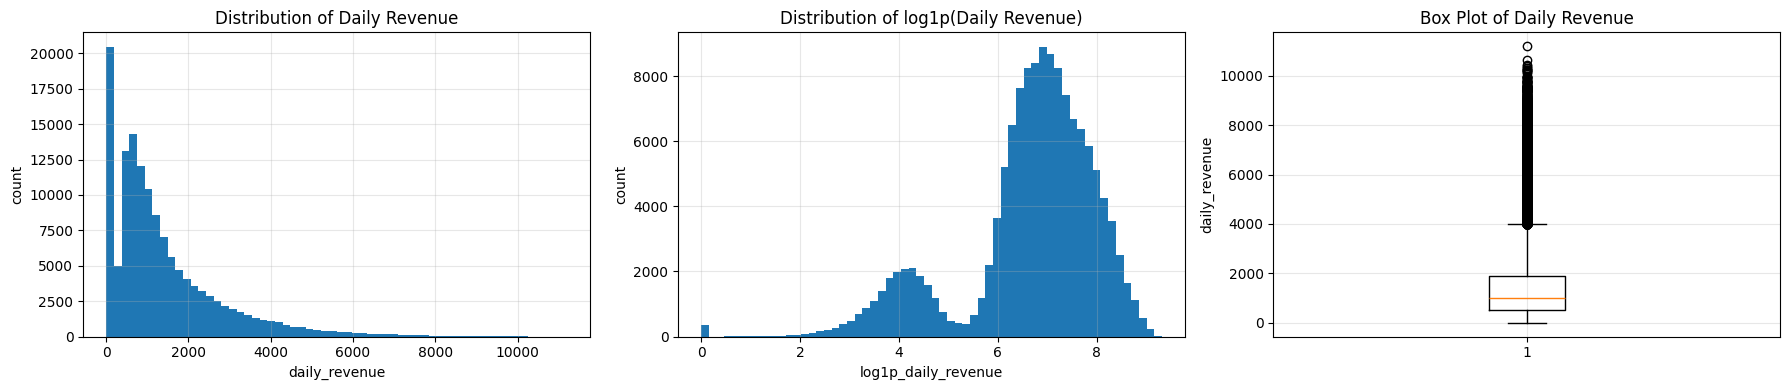

,observation,evidence,meaning,next_action
0,Doanh thu có xu hướng lệch phải,Mean thường lớn hơn median; histogram raw có đ...,Một số store-dept-day có doanh thu rất cao so ...,Khi model có thể dùng log transform hoặc metri...


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(m5_daily["daily_revenue"], bins=60)
axes[0].set_title("Distribution of Daily Revenue")
axes[0].set_xlabel("daily_revenue")
axes[0].set_ylabel("count")
axes[0].grid(True, alpha=0.3)

axes[1].hist(m5_daily["log1p_daily_revenue"], bins=60)
axes[1].set_title("Distribution of log1p(Daily Revenue)")
axes[1].set_xlabel("log1p_daily_revenue")
axes[1].set_ylabel("count")
axes[1].grid(True, alpha=0.3)

axes[2].boxplot(m5_daily["daily_revenue"], vert=True, showfliers=True)
axes[2].set_title("Box Plot of Daily Revenue")
axes[2].set_ylabel("daily_revenue")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

revenue_distribution_notes = pd.DataFrame(
    [
        {
            "observation": "Doanh thu có xu hướng lệch phải",
            "evidence": "Mean thường lớn hơn median; histogram raw có đuôi phải.",
            "meaning": "Một số store-dept-day có doanh thu rất cao so với phần lớn ngày bình thường.",
            "next_action": "Khi model có thể dùng log transform hoặc metric ít nhạy outlier như MAE/WAPE.",
        }
    ]
)

display(revenue_distribution_notes)

### Phân tích theo category và department

,cat_id,rows,total_revenue,total_units,avg_daily_revenue,median_daily_revenue,zero_revenue_pct,revenue_share_pct
0,FOODS,58230,"111,140,024.000",45922427,"1,908.639","1,263.740",0.220,58.013
2,HOUSEHOLD,38820,"57,115,876.000",14764090,"1,471.300","1,199.480",0.265,29.813
1,HOBBIES,38820,"23,321,644.000",6240656,600.764,197.150,0.340,12.173


,cat_id,dept_id,rows,total_revenue,total_units,avg_daily_revenue,median_daily_revenue,std_daily_revenue,max_daily_revenue,zero_revenue_pct,avg_price,avg_active_items,item_count,revenue_share_pct,cv_revenue
2,FOODS,FOODS_3,19410,"72,345,864.000",32937002,"3,727.247","3,440.680","1,553.028","11,198.950",0.124,2.201,341.124,823,37.763,0.417
5,HOUSEHOLD,HOUSEHOLD_1,19410,"42,132,780.000",11722853,"2,170.674","1,963.520","1,067.031","8,464.760",0.263,3.651,197.495,532,21.993,0.492
1,FOODS,FOODS_2,19410,"25,592,366.000",7795025,"1,318.515","1,226.625",737.940,"7,082.820",0.289,3.234,128.242,398,13.359,0.560
3,HOBBIES,HOBBIES_1,19410,"22,120,244.000",5699014,"1,139.631","1,025.985",532.674,"3,804.030",0.263,3.960,111.761,416,11.546,0.467
6,HOUSEHOLD,HOUSEHOLD_2,19410,"14,983,098.000",3041237,771.927,653.325,403.554,"3,115.390",0.268,4.899,99.830,515,7.821,0.523
0,FOODS,FOODS_1,19410,"13,201,796.000",5190400,680.154,631.045,288.164,"2,618.330",0.247,2.565,79.951,216,6.891,0.424
4,HOBBIES,HOBBIES_2,19410,"1,201,399.750",541642,61.896,55.765,36.129,306.690,0.417,2.368,17.346,149,0.627,0.584


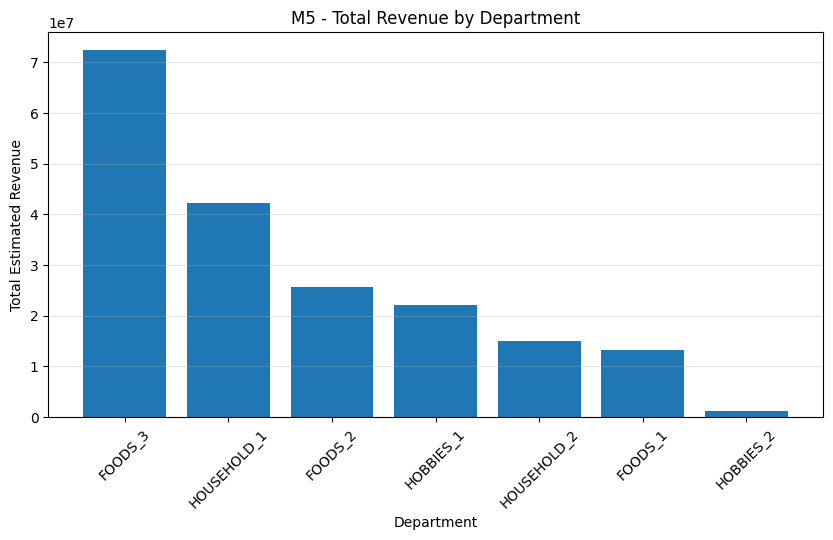

In [26]:
dept_summary = (
    m5_daily.groupby(["cat_id", "dept_id"], as_index=False)
    .agg(
        rows=("daily_revenue", "size"),
        total_revenue=("daily_revenue", "sum"),
        total_units=("daily_units", "sum"),
        avg_daily_revenue=("daily_revenue", "mean"),
        median_daily_revenue=("daily_revenue", "median"),
        std_daily_revenue=("daily_revenue", "std"),
        max_daily_revenue=("daily_revenue", "max"),
        zero_revenue_pct=("daily_revenue", lambda s: (s == 0).mean() * 100),
        avg_price=("weighted_avg_sell_price", "mean"),
        avg_active_items=("active_item_count", "mean"),
        item_count=("item_count", "max"),
    )
)

dept_summary["revenue_share_pct"] = dept_summary["total_revenue"] / dept_summary["total_revenue"].sum() * 100
dept_summary["cv_revenue"] = dept_summary["std_daily_revenue"] / dept_summary["avg_daily_revenue"]
dept_summary = dept_summary.sort_values("total_revenue", ascending=False)

cat_summary = (
    m5_daily.groupby("cat_id", as_index=False)
    .agg(
        rows=("daily_revenue", "size"),
        total_revenue=("daily_revenue", "sum"),
        total_units=("daily_units", "sum"),
        avg_daily_revenue=("daily_revenue", "mean"),
        median_daily_revenue=("daily_revenue", "median"),
        zero_revenue_pct=("daily_revenue", lambda s: (s == 0).mean() * 100),
    )
)
cat_summary["revenue_share_pct"] = cat_summary["total_revenue"] / cat_summary["total_revenue"].sum() * 100
cat_summary = cat_summary.sort_values("total_revenue", ascending=False)

display(cat_summary)
display(dept_summary)

plt.figure(figsize=(10, 5))
plt.bar(dept_summary["dept_id"], dept_summary["total_revenue"])
plt.title("M5 - Total Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Total Estimated Revenue")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Box plot doanh thu theo department

/var/folders/85/7c70lhcs3_qfctsnpspz53nw0000gn/T/ipykernel_15052/600564075.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=dept_order, showfliers=False)


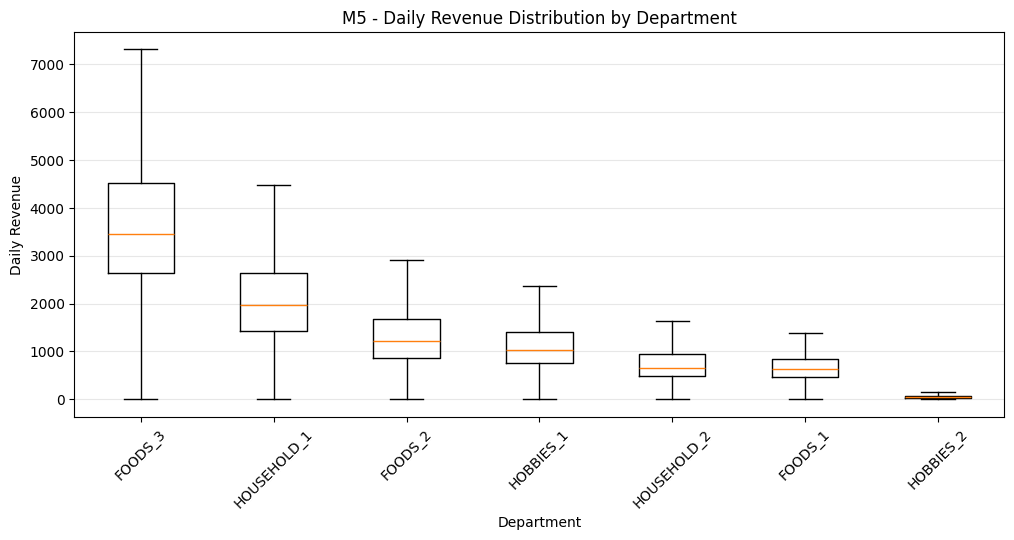

,note,interpretation,caution
0,Box plot không hiển thị outlier để dễ nhìn med...,Department có median cao và IQR rộng thường vừ...,Không xóa outlier chỉ vì box plot; cần xem out...


In [27]:
dept_order = dept_summary["dept_id"].tolist()
box_data = [m5_daily.loc[m5_daily["dept_id"] == dept, "daily_revenue"] for dept in dept_order]

plt.figure(figsize=(12, 5))
plt.boxplot(box_data, labels=dept_order, showfliers=False)
plt.title("M5 - Daily Revenue Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Daily Revenue")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

boxplot_notes = pd.DataFrame(
    [
        {
            "note": "Box plot không hiển thị outlier để dễ nhìn median/IQR.",
            "interpretation": "Department có median cao và IQR rộng thường vừa có doanh thu cao vừa biến động mạnh.",
            "caution": "Không xóa outlier chỉ vì box plot; cần xem outlier có phải ngày event/seasonality/store lớn hay không.",
        }
    ]
)

display(boxplot_notes)